In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving bank-additional-full.csv to bank-additional-full.csv


In [ ]:
data = pd.read_csv('bank-additional-full.csv', sep=';')

In [31]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
data['y'] = data['y'].map({'yes':1, 'no':0})

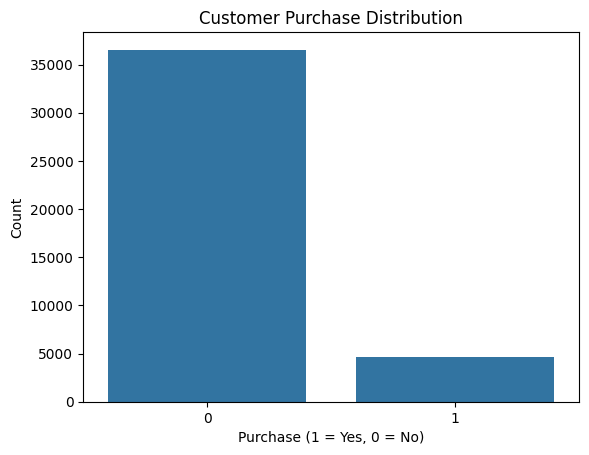

In [33]:
sns.countplot(x='y', data=data)
plt.title("Customer Purchase Distribution")
plt.xlabel("Purchase (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

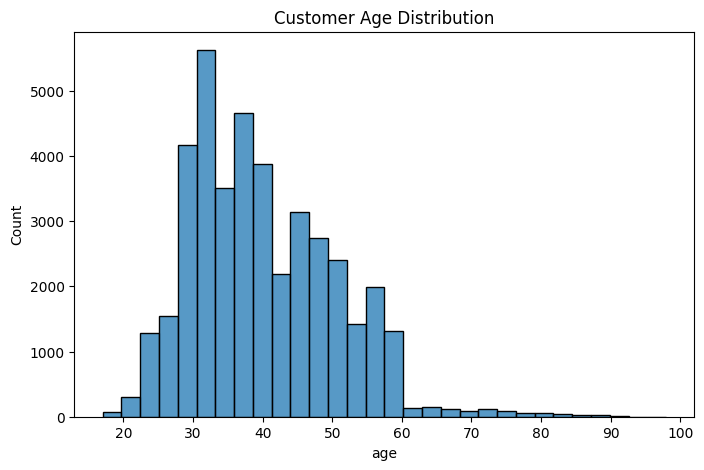

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(data['age'], bins=30)
plt.title("Customer Age Distribution")
plt.show()

In [35]:
data_encoded = pd.get_dummies(data, drop_first=True)

In [36]:
X = data_encoded.drop('y', axis=1)
y = data_encoded['y']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [38]:
clf = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=50,
    random_state=42
)

clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_split=50, random_state=42)

In [39]:
y_pred = clf.predict(X_test)

In [40]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9089584850691915


In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      7303
           1       0.60      0.59      0.60       935

    accuracy                           0.91      8238
   macro avg       0.77      0.77      0.77      8238
weighted avg       0.91      0.91      0.91      8238



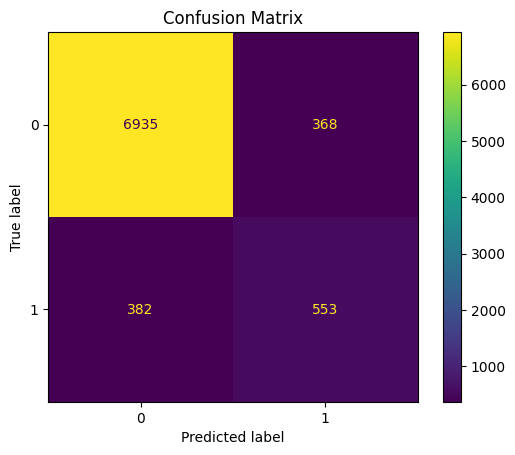

In [42]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

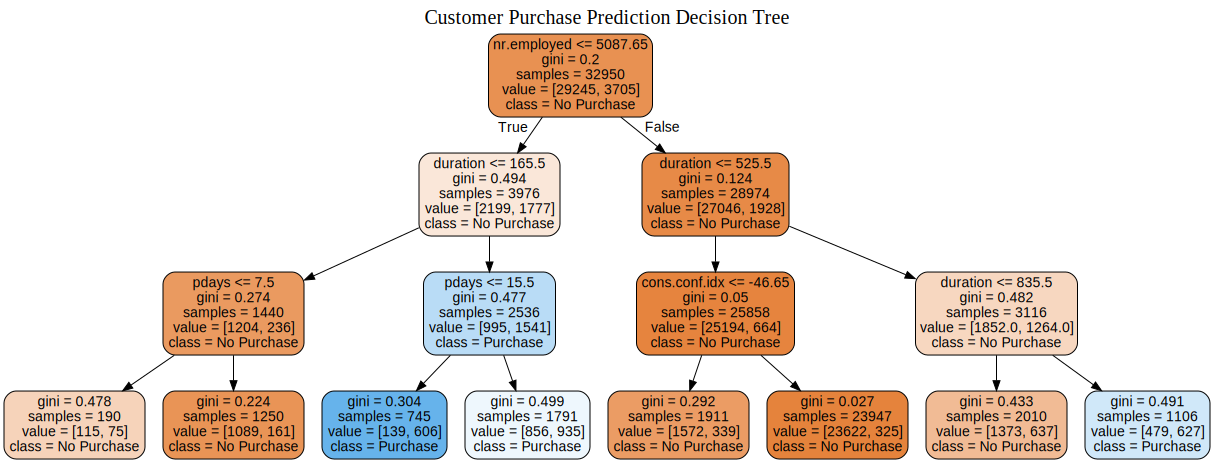

In [43]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    clf,
    out_file=None,
    feature_names=X.columns,
    class_names=['No Purchase','Purchase'],
    filled=True,
    rounded=True
)

# Insert graph attributes directly into the DOT string
graph_attrs = 'graph [label="Customer Purchase Prediction Decision Tree", labelloc="t", fontsize="20"];'
dot_data_with_attrs = dot_data.replace('digraph Tree {', f'digraph Tree {{\n    {graph_attrs}\n', 1)

graph = graphviz.Source(dot_data_with_attrs)
graph